In [1]:
# Enable automatic reloading of modules before executing code
%load_ext autoreload
%autoreload 2

In [2]:
import os
import copy

from functools import partial, reduce

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import pingouin as pg
from PIL import Image

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

import matplotlib.colors as mcolors

In [3]:
import utils as ut

In [4]:
pd.set_option('display.max_columns', 100)

In [5]:
# test run of the model for dev purposes, or full/final data set?
is_testcase = False

In [62]:
plt.rc('grid', linestyle='--', linewidth=0.5, color='gray')
sns.set_style("whitegrid")

# Load Model Results from Disk

In [15]:
model_path = "./results/ID-on-embeddings/SPoSE49/lambda0.001/lr0.0005/subjects_actual/splithalf_no/seed852/model/model_epoch0100.tar"
m = torch.load(model_path, weights_only=False, map_location=torch.device("cpu"))

In [51]:
l_data_subset = ["subjects_actual", "subjects_shuffled"]
l_splithalf = ["no", "1", "2"]
l_rnd_seed = [852]
modeltype = "SPoSE49"
modelversion = "ID-on-embeddings"
l_lmbda = [0.001, 0.000001]
l_lr = [0.0005]
latest_epoch = "model_epoch0100.tar"

# load results from model run
l_results_spose49 = ut.load_pretrained(
    l_data_subset, l_rnd_seed, modelversion, modeltype, l_lmbda, l_lr, l_splithalf, latest_epoch
)

### Analyze Predictive Power of Model with Pretrained 49D SPoSE embeddings (from Hebart et al. 2020)

In [54]:
test_accs_max = np.array([np.max(l["val_accs_max"]) for l in l_results_spose49])
test_accs_proba = np.array([np.max(l["val_accs_proba"]) for l in l_results_spose49])
subject_type = np.array([l["subject_type"] for l in l_results_spose49])
splithalf = np.array([l["splithalf"] for l in l_results_spose49])
lambdas = np.array([l["lmbda"] for l in l_results_spose49])
df_results = pd.DataFrame({
    "ArgMax":test_accs_max,
    "SoftMax":test_accs_proba,
    "Subject IDs":subject_type,
    "Splithalf":splithalf,
    "lambda":lambdas
})
df_plt = df_results.query('`Splithalf` not in ["1", "2"]').melt(id_vars=["Subject IDs", "Splithalf", "lambda"])

Text(0.5, -0.02, 'Note. Y axis range differs between panels')

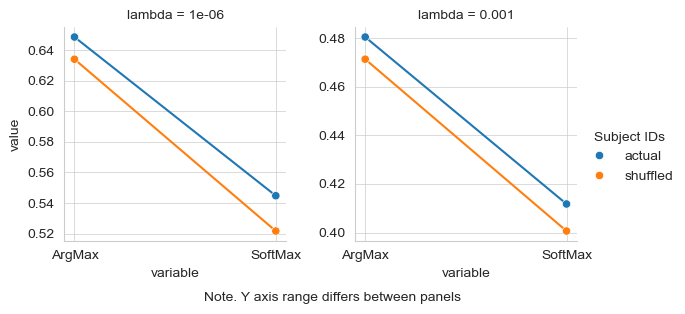

In [75]:
g = sns.FacetGrid(data=df_plt, col="lambda", sharey=False)
g.map_dataframe(sns.lineplot,  x="variable", y="value", hue="Subject IDs", zorder=1, legend=True)
g.map_dataframe(sns.scatterplot, x="variable", y="value", color="white", size=5, zorder=2, legend=False)
g.map_dataframe(sns.scatterplot, x="variable", y="value", hue="Subject IDs", zorder=3, legend=True)

g.add_legend(title="Subject IDs")
plt.figtext(0.5, -0.02, "Note. Y axis range differs between panels", ha="center", fontsize=10)

### Analyze Split-Half Reliability of 49Ds

let's use the best performing model, i.e., lambda = 1e-06, actual subject ids

In [79]:
df_results

,ArgMax,SoftMax,Subject IDs,Splithalf,lambda
0,0.480496,0.411763,actual,no,0.001000
1,0.497424,0.448479,actual,1,0.001000
2,0.497575,0.448873,actual,2,0.001000
3,0.648657,0.544785,actual,no,0.000001
4,0.652087,0.551232,actual,1,0.000001
5,0.651718,0.551347,actual,2,0.000001
6,0.471378,0.400632,shuffled,no,0.001000
7,0.497424,0.448479,shuffled,1,0.001000
8,0.497575,0.448873,shuffled,2,0.001000
9,0.634130,0.521680,shuffled,no,0.000001


In [97]:
l_idxs = df_results.query("`lambda` == 0.000001 and Splithalf != 'no'  and `Subject IDs` == 'actual'").index.values

In [102]:
l_splithalf = [l_results_spose49[idx] for idx in l_idxs]

In [107]:
df_first_half = pd.DataFrame(l_splithalf[0]["decision_weights"].detach().numpy())
df_first_half["pid_model"] = range(0, df_first_half.shape[0])
df_second_half = pd.DataFrame(l_splithalf[1]["decision_weights"].detach().numpy())
df_second_half["pid_model"] = range(0, df_second_half.shape[0])

In [112]:
df_weights_halves = pd.merge(
    df_first_half.melt(id_vars=["pid_model"]),
    df_second_half.melt(id_vars=["pid_model"]),
    how="left", on="pid_model", suffixes=["_first", "_second"]
)

In [116]:
def group_corr(df):
    return np.corrcoef(df["value_first"], df["value_second"])[0, 1]

In [114]:
df_weights_halves.head()

,pid_model,variable_first,value_first,variable_second,value_second
0,0,0,0.857646,0,0.830192
1,0,0,0.857646,1,0.945524
2,0,0,0.857646,2,0.815171
3,0,0,0.857646,3,1.117502
4,0,0,0.857646,4,0.858288


In [124]:
df_splithalf = df_weights_halves.groupby("variable_first").apply(group_corr, include_groups=False).reset_index().rename(columns={"variable_first":"Dimension"})

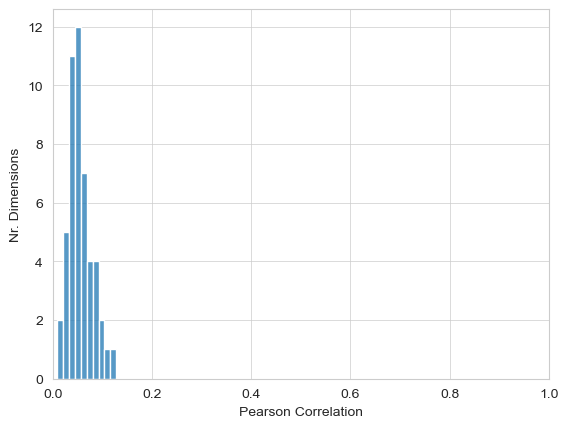

In [129]:
f, ax = plt.subplots(1)
sns.histplot(data=df_splithalf, x=0, ax=ax)
ax.set_xlim((0, 1))
ax.set_xlabel("Pearson Correlation")
_ = ax.set_ylabel("Nr. Dimensions")